# **1. Установка зависимостей**

# 1.1 Монтирование Google Drive  
Можно не монтировать гугл диск, а хранить все данные для выполнения дз в файлах ноутбука, но тогда репозиторий YOLO, результаты обучения и датасет не сохранятся при отключении от среды выполнения. То есть каждый раз надо будет клонировать репозиторий и загружать датасет, что не очень удобно.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


## Определяем видеокарту GPU, чтобы на ней учить нейронную сеть

In [ ]:
!nvidia-smi

Fri Jun  5 15:09:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# 1.2 Установка зависимостей

In [ ]:
%pip install ultralytics pycocotools opencv-python

import os
import json
import shutil
import yaml
import cv2
import numpy as np
import ultralytics

from pathlib import Path
from collections import defaultdict
from sklearn.model_selection import train_test_split

ultralytics.checks()

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


# **2. Импорт датасета**

Набор данных должен быть экспортирован из cvat в формате COCO 1.0.  

В бесплатной онлайн-версии нельзя экспортировать датасет вместе с картинками, если используется эта версия, картинки надо загружать отдельно. Если устанавливать cvat локально, такого ограничения нет.

Загрузите аннотации и картинки в одну папку и загрузите ее на google диск,туда же поместите файл instances_default.json.


**Примечание:** этот вариант ноутбука учитывает COCO segmentation в виде polygon и RLE-mask из CVAT, а также автоматически переводит `category_id` COCO в индексы классов YOLO, начиная с 0.

In [ ]:
def _safe_yolo_stem(image):
    """
    Делаем уникальное имя для картинки/label.
    Это защищает от ситуации, когда в разных подпапках лежат файлы с одинаковым именем.
    """
    original_stem = Path(image["file_name"]).stem
    return f"{int(image['id']):06d}_{original_stem}"


def _decode_uncompressed_rle(rle, height, width):
    """
    Декодирование COCO uncompressed RLE:
    segmentation = {"counts": [...], "size": [height, width]}
    """
    counts = rle["counts"]
    flat = np.zeros(height * width, dtype=np.uint8)

    index = 0
    value = 0

    for count in counts:
        count = int(count)
        end = min(index + count, height * width)

        if value == 1:
            flat[index:end] = 1

        index = end
        value = 1 - value

        if index >= height * width:
            break

    return flat.reshape((height, width), order="F")


def _decode_coco_rle(segmentation, image_height, image_width):
    """
    Декодирует RLE-mask из COCO.
    Поддерживает uncompressed RLE из CVAT.
    Если встретится compressed RLE, пробует pycocotools.
    """
    counts = segmentation.get("counts")

    if isinstance(counts, list):
        return _decode_uncompressed_rle(segmentation, image_height, image_width)

    # На случай compressed RLE
    try:
        from pycocotools import mask as mask_utils
        mask = mask_utils.decode(segmentation)
        return mask.astype(np.uint8)
    except Exception as exc:
        raise RuntimeError(
            "Не удалось декодировать RLE segmentation. "
            "Для compressed RLE нужен установленный pycocotools."
        ) from exc


def _rle_to_polygons(segmentation, image_width, image_height, epsilon=2.0):
    """
    Переводит RLE-mask в polygon-контуры для YOLO segmentation.
    """
    mask = _decode_coco_rle(segmentation, image_height, image_width)

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    polygons = []

    for contour in contours:
        if len(contour) < 3:
            continue

        approx = cv2.approxPolyDP(
            contour,
            epsilon=epsilon,
            closed=True
        )

        polygon = approx.reshape(-1, 2).astype(float).flatten().tolist()

        if len(polygon) >= 6:
            polygons.append(polygon)

    return polygons


def convert_coco_to_yolo_segmentation(json_file, folder_name="labels"):
    """
    Конвертация COCO 1.0 segmentation из CVAT в YOLOv8 segmentation.

    Исправления относительно исходной функции:
    1. Работает не только с polygon segmentation, но и с RLE-mask / iscrowd=1.
    2. Переводит COCO category_id 1,2,3 в YOLO class_id 0,1,2.
    3. Создает отдельный .txt для каждого изображения.
    4. Не дублирует строки при повторном запуске.
    """
    json_file = Path(json_file)
    dataset_dir = json_file.parent

    with open(json_file, "r", encoding="utf-8") as file:
        coco_data = json.load(file)

    # folder_name лучше передавать как "labels".
    # Если случайно передан абсолютный путь, используем его как есть.
    folder_name = Path(folder_name)
    output_folder = folder_name if folder_name.is_absolute() else dataset_dir / folder_name
    output_folder.mkdir(parents=True, exist_ok=True)

    # Удаляем только txt из корня labels, чтобы при повторном запуске не было дублей.
    # labels/train, labels/val, labels/test эта строка не трогает.
    for txt_file in output_folder.glob("*.txt"):
        txt_file.unlink()

    images_by_id = {
        image["id"]: image
        for image in coco_data["images"]
    }

    categories = sorted(coco_data["categories"], key=lambda x: x["id"])
    category_id_to_yolo_id = {
        category["id"]: index
        for index, category in enumerate(categories)
    }

    labels_by_image = defaultdict(list)
    polygon_count = 0
    rle_count = 0
    skipped_count = 0

    for annotation in coco_data["annotations"]:
        image_id = annotation["image_id"]
        category_id = annotation["category_id"]
        segmentation = annotation.get("segmentation")

        image = images_by_id[image_id]
        image_width = image["width"]
        image_height = image["height"]
        image_stem = _safe_yolo_stem(image)

        yolo_class_id = category_id_to_yolo_id[category_id]

        if isinstance(segmentation, list):
            polygons = segmentation
            polygon_count += 1
        elif isinstance(segmentation, dict):
            polygons = _rle_to_polygons(segmentation, image_width, image_height)
            rle_count += 1
        else:
            skipped_count += 1
            continue

        for polygon in polygons:
            if len(polygon) < 6:
                continue

            yolo_points = []

            for x, y in zip(polygon[::2], polygon[1::2]):
                x_norm = max(0.0, min(1.0, float(x) / image_width))
                y_norm = max(0.0, min(1.0, float(y) / image_height))

                yolo_points.append(f"{x_norm:.6f}")
                yolo_points.append(f"{y_norm:.6f}")

            if len(yolo_points) >= 6:
                labels_by_image[image_stem].append(
                    f"{yolo_class_id} " + " ".join(yolo_points)
                )

    # Создаем .txt для каждого изображения, даже если объектов вдруг нет.
    for image in coco_data["images"]:
        image_stem = _safe_yolo_stem(image)
        output_filename = output_folder / f"{image_stem}.txt"

        with open(output_filename, "w", encoding="utf-8") as file:
            file.write("\n".join(labels_by_image[image_stem]))

    print("Conversion completed.")
    print(f"YOLO labels saved to: {output_folder}")
    print(f"Polygon annotations: {polygon_count}")
    print(f"RLE/mask annotations converted: {rle_count}")
    print(f"Skipped annotations: {skipped_count}")
    print("Class mapping:")

    for category in categories:
        print(f"COCO {category['id']} -> YOLO {category_id_to_yolo_id[category['id']]}: {category['name']}")


# Example usage
json_file = "/content/gdrive/MyDrive/dataset/instances_default.json"
split = "labels"
convert_coco_to_yolo_segmentation(json_file, split)

Conversion completed.
YOLO labels saved to: /content/gdrive/MyDrive/dataset/labels
Polygon annotations: 256
RLE/mask annotations converted: 61
Skipped annotations: 0
Class mapping:
COCO 1 -> YOLO 0: motorcycles
COCO 2 -> YOLO 1: ATV
COCO 3 -> YOLO 2: Scooter


In [ ]:
dataset_path = '/content/gdrive/MyDrive/dataset' # Укажите свой путь до датасета

In [ ]:
test_size = 0.2 # размер тестовой выборки
valid_size = 0.1 # размер валидационной выборки

In [ ]:
json_file = os.path.join(dataset_path, "instances_default.json")
labels_source_dir = os.path.join(dataset_path, "labels")

with open(json_file, "r", encoding="utf-8") as file:
    coco_data = json.load(file)

image_extensions = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

records = []
missing_images = []
missing_labels = []

for image in coco_data["images"]:
    image_rel_path = image["file_name"]

    # 1) если в JSON путь вида images/class/file.jpg
    image_path = os.path.join(dataset_path, image_rel_path)

    # 2) если картинки лежат прямо в dataset_path, а в JSON только basename
    if not os.path.exists(image_path):
        image_path = os.path.join(dataset_path, os.path.basename(image_rel_path))

    if not os.path.exists(image_path):
        missing_images.append(image_rel_path)
        continue

    suffix = Path(image_path).suffix.lower()
    if suffix not in image_extensions:
        continue

    yolo_stem = _safe_yolo_stem(image)
    label_path = os.path.join(labels_source_dir, f"{yolo_stem}.txt")

    if not os.path.exists(label_path):
        missing_labels.append(label_path)
        continue

    records.append({
        "image_path": image_path,
        "label_path": label_path,
        "yolo_stem": yolo_stem,
        "suffix": suffix,
    })

print(f"Images prepared for split: {len(records)}")
print(f"Missing images: {len(missing_images)}")
print(f"Missing labels: {len(missing_labels)}")

if len(records) == 0:
    raise RuntimeError(
        "Не найдено ни одной пары image + label. "
        "Проверь dataset_path, наличие картинок и запуск convert_coco_to_yolo_segmentation()."
    )

train_records, test_records = train_test_split(
    records,
    test_size=test_size,
    random_state=42
)

val_fraction_from_train = len(records) * valid_size / len(train_records)
train_records, valid_records = train_test_split(
    train_records,
    test_size=val_fraction_from_train,
    random_state=42
)

# Пересоздаем только train/val/test, исходные картинки и instances_default.json не удаляем.
for folder in ["train", "val", "test"]:
    images_folder = os.path.join(dataset_path, "images", folder)
    labels_folder = os.path.join(dataset_path, "labels", folder)

    shutil.rmtree(images_folder, ignore_errors=True)
    shutil.rmtree(labels_folder, ignore_errors=True)

    os.makedirs(images_folder, exist_ok=True)
    os.makedirs(labels_folder, exist_ok=True)


def copy_records(records_subset, folder):
    for item in records_subset:
        image_dest = os.path.join(
            dataset_path,
            "images",
            folder,
            f"{item['yolo_stem']}{item['suffix']}"
        )

        label_dest = os.path.join(
            dataset_path,
            "labels",
            folder,
            f"{item['yolo_stem']}.txt"
        )

        shutil.copy(item["image_path"], image_dest)
        shutil.copy(item["label_path"], label_dest)


copy_records(train_records, "train")
copy_records(valid_records, "val")
copy_records(test_records, "test")

print(f"Train: {len(train_records)}")
print(f"Val: {len(valid_records)}")
print(f"Test: {len(test_records)}")

Images prepared for split: 300
Missing images: 0
Missing labels: 0
Train: 210
Val: 30
Test: 60


In [ ]:
train_path = "images/train"
val_path = "images/val"
test_path = "images/test"

json_file = os.path.join(dataset_path, "instances_default.json")

with open(json_file, "r", encoding="utf-8") as file:
    coco_data = json.load(file)

categories = sorted(coco_data["categories"], key=lambda x: x["id"])
class_names = {
    index: category["name"]
    for index, category in enumerate(categories)
}

data = {
    "path": dataset_path,
    "train": train_path,
    "val": val_path,
    "test": test_path,
    "nc": len(class_names),
    "names": class_names,
}

output_file = os.path.join(dataset_path, "data.yaml")

with open(output_file, "w", encoding="utf-8") as file:
    yaml.dump(data, file, allow_unicode=True, sort_keys=False)

print(f"data.yaml saved to: {output_file}")
print(data)

data.yaml saved to: /content/gdrive/MyDrive/dataset/data.yaml
{'path': '/content/gdrive/MyDrive/dataset', 'train': 'images/train', 'val': 'images/val', 'test': 'images/test', 'nc': 3, 'names': {0: 'motorcycles', 1: 'ATV', 2: 'Scooter'}}


# **3. Запуск обучения**

In [ ]:
%cd /content/gdrive/MyDrive

/content/gdrive/MyDrive


# 3.1 Начало обучения

[Чтобы получить полный список аргументов обучения, перейдите по ссылке](https://docs.ultralytics.com/modes/train/#train-settings)


In [ ]:
# Load YOLOv8n-seg and train it on your dataset
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

model.train(
    data=os.path.join(dataset_path, "data.yaml"),
    epochs=15,
    batch=32,
    imgsz=640,
    device=0
)

# Prediction on the prepared test folder
model.predict(
    source=os.path.join(dataset_path, "images", "test"),
    save=True
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/gdrive/MyDrive/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: 'motorcycles', 1: 'ATV', 2: 'Scooter'}
 obb: None
 orig_img: array([[[247, 245, 244],
         [247, 245, 244],
         [247, 245, 244],
         ...,
         [247, 245, 244],
         [247, 245, 244],
         [247, 245, 244]],
 
        [[247, 245, 244],
         [247, 245, 244],
         [247, 245, 244],
         ...,
         [247, 245, 244],
         [247, 245, 244],
         [247, 245, 244]],
 
        [[247, 245, 244],
         [247, 245, 244],
         [247, 245, 244],
         ...,
         [247, 245, 244],
         [247, 245, 244],
         [247, 245, 244]],
 
        ...,
 
        [[247, 245, 244],
         [247, 245, 244],
         [247, 245, 244],
         ...,
         [247, 245, 244],
         [247, 245, 244],
         [247, 245, 244]],
 
        [[247, 245, 244],
         [247, 245, 

# **4. Экспорт модели в onnx**

In [ ]:
!pip install ultralytics onnx onnx-simplifier onnxruntime

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 98.2 MB/s eta 0:00:00
  Created wheel for onnx-simplifier: filename=onnx_simplifier-0.5.0-py3-none-any.whl size=1021 sha256=261e7a100e352f751fd747cf4ec51562c661f0a48e320a1a856a29d4c04bcb59
  Stored in directory: /root/.cache/pip/wheels/f0/61/52/656a88deb2107e0239543f2bdfab560c47fcf74c3d29765c5e
Successfully built onnx-simplifier


In [ ]:
from ultralytics import YOLO
from pathlib import Path

# Берем последний обученный best.pt из runs/segment/train*/weights/best.pt
runs_dir = Path("/content/gdrive/MyDrive/runs/segment")
best_weights = sorted(
    runs_dir.glob("train*/weights/best.pt"),
    key=lambda path: path.stat().st_mtime,
    reverse=True
)

if not best_weights:
    raise FileNotFoundError(
        "Не найден best.pt. Сначала запусти ячейку обучения."
    )

weights_path = str(best_weights[0])
print(f"Using weights: {weights_path}")

model = YOLO(weights_path)

# Export to ONNX
onnx_file = model.export(format="onnx")

# Load an ONNX model
onnx_model = YOLO(onnx_file)

# Run inference with ONNXRuntime on test images
results = onnx_model(os.path.join(dataset_path, "images", "test"))

Using weights: /content/gdrive/MyDrive/runs/segment/train-8/weights/best.pt
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLOv8n-seg summary (fused): 86 layers, 3,258,649 parameters, 0 gradients, 11.3 GFLOPs

PyTorch: starting from '/content/gdrive/MyDrive/runs/segment/train-8/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 39, 8400), (1, 32, 160, 160)) (6.5 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 10 packages in 532ms
Prepared 2 packages in 49ms
Installed 2 packages in 10ms
 + colorama==0.4.6
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with o

In [ ]:
print(results)

[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: 'motorcycles', 1: 'ATV', 2: 'Scooter'}
obb: None
orig_img: array([[[247, 245, 244],
        [247, 245, 244],
        [247, 245, 244],
        ...,
        [247, 245, 244],
        [247, 245, 244],
        [247, 245, 244]],

       [[247, 245, 244],
        [247, 245, 244],
        [247, 245, 244],
        ...,
        [247, 245, 244],
        [247, 245, 244],
        [247, 245, 244]],

       [[247, 245, 244],
        [247, 245, 244],
        [247, 245, 244],
        ...,
        [247, 245, 244],
        [247, 245, 244],
        [247, 245, 244]],

       ...,

       [[247, 245, 244],
        [247, 245, 244],
        [247, 245, 244],
        ...,
        [247, 245, 244],
        [247, 245, 244],
        [247, 245, 244]],

       [[247, 245, 244],
        [247, 245, 244],
        [247, 245, 244],
        ...

# **5. Подбор лучшего IoU-порога по метрикам**

В этом блоке подбирается порог IoU для тестовой выборки.  
Идея такая: для каждого изображения сравниваем предсказанные маски YOLO с истинными масками из `labels/test`.

Предсказание считается **TP**, если:
1. класс предсказания совпал с классом истинного объекта;
2. IoU между масками больше или равен выбранному порогу;
3. один истинный объект сопоставляется только с одним предсказанием.

По таблице метрик выбираем лучший порог, обычно по максимальному `F1`.


Using weights: /content/gdrive/MyDrive/runs/segment/train-8/weights/best.pt
Test images: 60
Prepared test items: 60


,iou_threshold,TP,FP,FN,precision,recall,f1,accuracy,mean_matched_iou
0,0.10,56,2,14,0.9655,0.8000,0.8750,0.7778,0.9333
1,0.15,56,2,14,0.9655,0.8000,0.8750,0.7778,0.9333
2,0.20,56,2,14,0.9655,0.8000,0.8750,0.7778,0.9333
3,0.25,56,2,14,0.9655,0.8000,0.8750,0.7778,0.9333
4,0.30,56,2,14,0.9655,0.8000,0.8750,0.7778,0.9333
5,0.35,56,2,14,0.9655,0.8000,0.8750,0.7778,0.9333
6,0.40,56,2,14,0.9655,0.8000,0.8750,0.7778,0.9333
7,0.45,56,2,14,0.9655,0.8000,0.8750,0.7778,0.9333
8,0.50,56,2,14,0.9655,0.8000,0.8750,0.7778,0.9333
9,0.55,56,2,14,0.9655,0.8000,0.8750,0.7778,0.9333


Лучший IoU-порог по F1: 0.65 | F1=0.8750 | Precision=0.9655 | Recall=0.8000 | Accuracy=0.7778
Metrics saved to: /content/gdrive/MyDrive/dataset/iou_threshold_metrics.csv


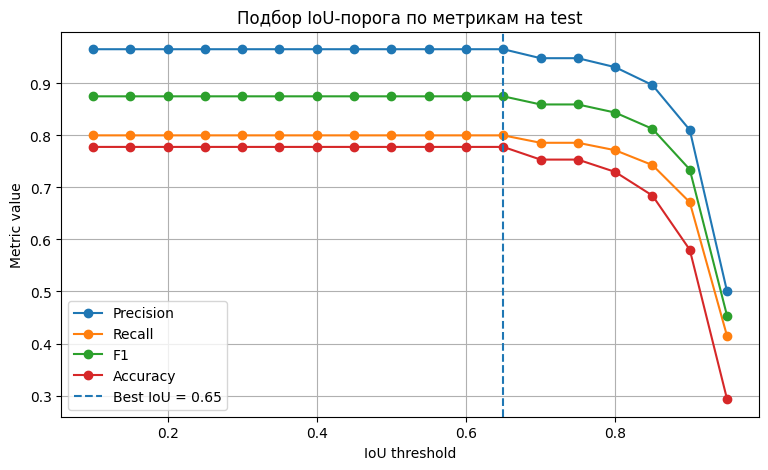

In [ ]:

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

def read_yolo_segmentation_labels(label_path, image_shape):
    """
    Читает YOLO segmentation label:
    class_id x1 y1 x2 y2 ... xn yn

    Координаты в YOLO нормализованные, поэтому переводим их в пиксели
    и строим бинарные маски.
    """
    height, width = image_shape[:2]
    objects = []

    if not os.path.exists(label_path):
        return objects

    with open(label_path, "r", encoding="utf-8") as file:
        lines = [line.strip() for line in file.readlines() if line.strip()]

    for line in lines:
        parts = line.split()

        if len(parts) < 7:
            continue

        class_id = int(float(parts[0]))
        coords = list(map(float, parts[1:]))

        points = []
        for x_norm, y_norm in zip(coords[::2], coords[1::2]):
            x = int(round(x_norm * width))
            y = int(round(y_norm * height))
            x = max(0, min(width - 1, x))
            y = max(0, min(height - 1, y))
            points.append([x, y])

        if len(points) < 3:
            continue

        mask = np.zeros((height, width), dtype=np.uint8)
        polygon = np.array(points, dtype=np.int32)
        cv2.fillPoly(mask, [polygon], 1)

        objects.append({
            "class_id": class_id,
            "mask": mask
        })

    return objects


def polygon_to_mask(points, image_shape):
    """
    Переводит polygon из Ultralytics result.masks.xy в бинарную маску.
    """
    height, width = image_shape[:2]
    mask = np.zeros((height, width), dtype=np.uint8)

    if points is None or len(points) < 3:
        return mask

    polygon = np.array(points, dtype=np.int32)
    polygon[:, 0] = np.clip(polygon[:, 0], 0, width - 1)
    polygon[:, 1] = np.clip(polygon[:, 1], 0, height - 1)

    cv2.fillPoly(mask, [polygon], 1)
    return mask


def calculate_mask_iou(mask_1, mask_2):
    """
    IoU = площадь пересечения / площадь объединения.
    """
    intersection = np.logical_and(mask_1, mask_2).sum()
    union = np.logical_or(mask_1, mask_2).sum()

    if union == 0:
        return 0.0

    return intersection / union


def extract_predictions_from_result(result, image_shape):
    """
    Достает из результата YOLO классы, confidence и маски.
    """
    predictions = []

    if result.masks is None or result.boxes is None:
        return predictions

    pred_classes = result.boxes.cls.cpu().numpy().astype(int)
    pred_confidences = result.boxes.conf.cpu().numpy()

    for class_id, confidence, polygon in zip(
        pred_classes,
        pred_confidences,
        result.masks.xy
    ):
        mask = polygon_to_mask(polygon, image_shape)

        predictions.append({
            "class_id": int(class_id),
            "confidence": float(confidence),
            "mask": mask
        })

    # Сначала сопоставляем более уверенные предсказания
    predictions = sorted(
        predictions,
        key=lambda item: item["confidence"],
        reverse=True
    )

    return predictions


def evaluate_iou_threshold(dataset_items, iou_threshold):
    """
    Считает TP, FP, FN и метрики для одного IoU-порога.
    """
    tp = 0
    fp = 0
    fn = 0
    matched_ious = []

    for item in dataset_items:
        gt_objects = item["gt_objects"]
        predictions = item["predictions"]

        matched_gt_indices = set()

        for prediction in predictions:
            best_iou = 0.0
            best_gt_index = None

            for gt_index, gt_object in enumerate(gt_objects):
                if gt_index in matched_gt_indices:
                    continue

                # Для корректного TP класс тоже должен совпасть
                if prediction["class_id"] != gt_object["class_id"]:
                    continue

                iou = calculate_mask_iou(prediction["mask"], gt_object["mask"])

                if iou > best_iou:
                    best_iou = iou
                    best_gt_index = gt_index

            if best_gt_index is not None and best_iou >= iou_threshold:
                tp += 1
                matched_gt_indices.add(best_gt_index)
                matched_ious.append(best_iou)
            else:
                fp += 1

        fn += len(gt_objects) - len(matched_gt_indices)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    # Object-level accuracy через TP / все ошибки.
    # Для детекции/сегментации чаще используют F1, но accuracy полезно показать в отчете.
    accuracy = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0.0

    mean_iou = float(np.mean(matched_ious)) if matched_ious else 0.0

    return {
        "iou_threshold": round(float(iou_threshold), 2),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
        "mean_matched_iou": mean_iou
    }


# --- 1. Загружаем лучшую обученную модель ---
runs_dir = Path("/content/gdrive/MyDrive/runs/segment")
best_weights = sorted(
    runs_dir.glob("train*/weights/best.pt"),
    key=lambda path: path.stat().st_mtime,
    reverse=True
)

if not best_weights:
    raise FileNotFoundError(
        "Не найден best.pt. Сначала запусти ячейку обучения."
    )

weights_path = str(best_weights[0])
print(f"Using weights: {weights_path}")

model = YOLO(weights_path)

# --- 2. Собираем test-изображения и делаем предсказания ---
test_images_dir = Path(dataset_path) / "images" / "test"
test_labels_dir = Path(dataset_path) / "labels" / "test"

image_paths = sorted(
    [
        path for path in test_images_dir.iterdir()
        if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
    ]
)

print(f"Test images: {len(image_paths)}")

# conf здесь НЕ подбираем, потому что задание про IoU-порог.
# При необходимости confidence-порог можно подобрать отдельным циклом.
prediction_results = model.predict(
    source=[str(path) for path in image_paths],
    conf=0.25,
    save=False,
    verbose=False
)

dataset_items = []

for image_path, result in zip(image_paths, prediction_results):
    image = cv2.imread(str(image_path))

    if image is None:
        print(f"Не удалось прочитать изображение: {image_path}")
        continue

    label_path = test_labels_dir / f"{image_path.stem}.txt"

    gt_objects = read_yolo_segmentation_labels(
        label_path=str(label_path),
        image_shape=image.shape
    )

    predictions = extract_predictions_from_result(
        result=result,
        image_shape=image.shape
    )

    dataset_items.append({
        "image_path": str(image_path),
        "gt_objects": gt_objects,
        "predictions": predictions
    })

print(f"Prepared test items: {len(dataset_items)}")

# --- 3. Подбираем IoU-порог ---
iou_thresholds = np.arange(0.10, 0.96, 0.05)

metrics = [
    evaluate_iou_threshold(dataset_items, threshold)
    for threshold in iou_thresholds
]

metrics_df = pd.DataFrame(metrics)

# Округляем только для красивого вывода
display_df = metrics_df.copy()
for column in ["precision", "recall", "f1", "accuracy", "mean_matched_iou"]:
    display_df[column] = display_df[column].round(4)

display(display_df)

# Лучший порог выбираем по F1.
# Если F1 одинаковый, берем более строгий порог IoU.
best_row = (
    metrics_df
    .sort_values(["f1", "iou_threshold"], ascending=[False, False])
    .iloc[0]
)

print(
    "Лучший IoU-порог по F1: "
    f"{best_row['iou_threshold']:.2f} | "
    f"F1={best_row['f1']:.4f} | "
    f"Precision={best_row['precision']:.4f} | "
    f"Recall={best_row['recall']:.4f} | "
    f"Accuracy={best_row['accuracy']:.4f}"
)

# --- 4. Сохраняем таблицу и строим график ---
metrics_output_path = Path(dataset_path) / "iou_threshold_metrics.csv"
metrics_df.to_csv(metrics_output_path, index=False)
print(f"Metrics saved to: {metrics_output_path}")

plt.figure(figsize=(9, 5))
plt.plot(metrics_df["iou_threshold"], metrics_df["precision"], marker="o", label="Precision")
plt.plot(metrics_df["iou_threshold"], metrics_df["recall"], marker="o", label="Recall")
plt.plot(metrics_df["iou_threshold"], metrics_df["f1"], marker="o", label="F1")
plt.plot(metrics_df["iou_threshold"], metrics_df["accuracy"], marker="o", label="Accuracy")

plt.axvline(
    best_row["iou_threshold"],
    linestyle="--",
    label=f"Best IoU = {best_row['iou_threshold']:.2f}"
)

plt.xlabel("IoU threshold")
plt.ylabel("Metric value")
plt.title("Подбор IoU-порога по метрикам на test")
plt.grid(True)
plt.legend()
plt.show()
